
# Computer Exercise 10.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.2 Quasi-Monte Carlo — *Low-Discrepancy Sequences (Van der Corput / Halton / Lattice)*
> **풀이 일자**: Day 38
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **2.** Implement the **Van der Corput** sequence (radical inverse), the
> multi-dimensional **Halton** sequence (distinct prime bases per axis), and a
> **rank-1 lattice (Kronecker / Roberts) sequence**. (a) Plot the first $N$ points of a
> pseudo-random sample, a Halton set, and a lattice set in the unit square and compare
> how evenly they fill it. (b) Use these *quasi-random* points to estimate a smooth
> integral over $[0,1]^d$ and show that the **quasi-Monte Carlo (QMC)** error decreases
> roughly like $\mathcal{O}\big(N^{-1}(\log N)^d\big)$ — far faster than the
> $\mathcal{O}(N^{-1/2})$ of ordinary Monte Carlo. *(Sobol is another popular
> low-discrepancy choice; here we build everything from scratch with NumPy only.)*

### 한국어 풀이용 정리
**난수를 일부러 "골고루" 배치**하는 저불일치 수열을 직접 만든다 — Van der Corput -> Halton,
그리고 **rank-1 격자(Kronecker/Roberts)** 수열. (a) 같은 점 개수에서 **유사난수는 뭉치고
빈틈이 생기지만, Halton·격자는 균일하게 공간을 채움**을 본다. (b) 그 점들로 적분하면 오차가
MC의 $N^{-1/2}$ 가 아니라 거의 $N^{-1}$ 로 떨어짐을 확인한다. (Sobol 도 대표적 저불일치 수열이지만,
여기서는 외부 패키지 없이 NumPy 만으로 전부 구현한다.)



## 2. 수학적 배경

### 2.1 라디칼 역(radical inverse)과 Van der Corput
정수 $k$ 를 밑 $b$ 로 전개 $k=\sum_j a_j b^{j}$ 한 뒤 소수점에 **거울처럼 반사**:
$$
\phi_b(k)=\sum_j a_j\,b^{-j-1}\in[0,1).
$$
$b=2$ 면 Van der Corput 수열. 다차원 **Halton**은 축마다 *서로 다른 소수* 밑을 쓴다:
$\mathbf{x}_k=(\phi_{2}(k),\phi_{3}(k),\phi_{5}(k),\dots)$.

### 2.2 rank-1 격자(Kronecker / Roberts $R_d$) 수열
무리수 벡터 $\boldsymbol\alpha$ 에 대해
$$
\mathbf{x}_k=\big(\tfrac12+k\,\boldsymbol\alpha\big)\bmod 1.
$$
Roberts 의 일반화 황금비 $\varphi_d$ ($\varphi_d^{d+1}=\varphi_d+1$ 의 해)를 써서
$\alpha_i=\varphi_d^{-i}$ 로 두면 모든 차원에서 *고르게 퍼지는* 저불일치 점열이 된다.

### 2.3 불일치(discrepancy)와 Koksma-Hlawka 부등식
점집합 $P=\{\mathbf{x}_k\}$ 의 **star discrepancy** $D_N^*$ 는 "어떤 축평행 상자에서도
점의 비율이 부피와 얼마나 어긋나는가"의 최댓값이다. 유계변동 함수 $g$ 에 대해
$$
\boxed{\;
\Big|\hat I_N-I\Big|\le V(g)\,D_N^{*}(P).
\;}
$$
유사난수는 $D_N^*\sim\sqrt{\log\log N/N}$, **저불일치 수열은 $D_N^*\sim (\log N)^d/N$**.
따라서 QMC 오차 $\sim\mathcal{O}(N^{-1}(\log N)^d)$ — 차수가 $-1/2$ 에서 거의 $-1$ 로.

### 2.4 결정론적 vs 확률적
QMC 점은 **무작위가 아니다**(결정론적). 그래서 표준오차 같은 확률적 오차막대는
바로 안 나온다 — 그 문제는 다음 문제(랜덤화 QMC)에서 다룬다.



## 3. 풀이 흐름

1. **radical inverse** $\phi_b(k)$ 를 벡터화로 구현 -> Van der Corput / Halton 생성기.
2. **rank-1 격자** 생성기: 일반화 황금비 $\varphi_d$ 로 $\boldsymbol\alpha$ 구성.
3. **시각화 (a)**: 동일 $N=256$ 에서 pseudo-random / Halton / Lattice 의 2-D 산점도 비교.
4. **적분 (b)**: 매끄러운 $g$ 를 $d=2,4$ 에서 MC vs Halton vs Lattice 로 추정.
5. **수렴 그래프**: $\log N$-$\log|\text{error}|$, 기준선 $-1/2$(MC) 와 $-1$(QMC) 비교.
6. **차원 효과 맛보기**: $d=4$ 에서 $(\log N)^d$ 항 때문에 기울기가 조금 완만해짐 관찰.
7. **해석**: "골고루 채우기"가 곧 "작은 불일치"이고 그것이 곧 작은 오차.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(38)

# --- radical inverse (벡터화): 정수배열 k -> phi_b(k) ---
def radical_inverse(k, b):
    k = np.asarray(k, dtype=np.int64).copy()
    f = np.ones_like(k, dtype=float)
    out = np.zeros_like(k, dtype=float)
    while np.any(k > 0):
        f = f / b
        out = out + f * (k % b)
        k = k // b
    return out

_FIRST_PRIMES = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
def halton(N, d, skip=1):
    k = np.arange(skip, skip + N)
    return np.stack([radical_inverse(k, _FIRST_PRIMES[i]) for i in range(d)], axis=1)

# --- rank-1 lattice (Kronecker / Roberts R_d) ---
def _gen_phi(d):
    x = 2.0
    for _ in range(60):                 # phi^(d+1) = phi + 1 의 해로 수렴
        x = (1.0 + x) ** (1.0 / (d + 1))
    return x
def lattice(N, d, skip=1):
    phi = _gen_phi(d)
    alpha = (1.0 / phi) ** np.arange(1, d + 1)
    k = np.arange(skip, skip + N).reshape(-1, 1)
    return (0.5 + k * alpha) % 1.0

# 검증: Van der Corput 첫 8개 (밑 2) = 1/2,1/4,3/4,1/8,5/8,3/8,7/8,1/16
print("Van der Corput base-2 :", np.round(radical_inverse(np.arange(1, 9), 2), 4))
print("lattice alpha (d=2)   :", np.round((1/_gen_phi(2))**np.arange(1,3), 5))


Van der Corput base-2 : [0.5    0.25   0.75   0.125  0.625  0.375  0.875  0.0625]
lattice alpha (d=2)   : [0.75488 0.56984]


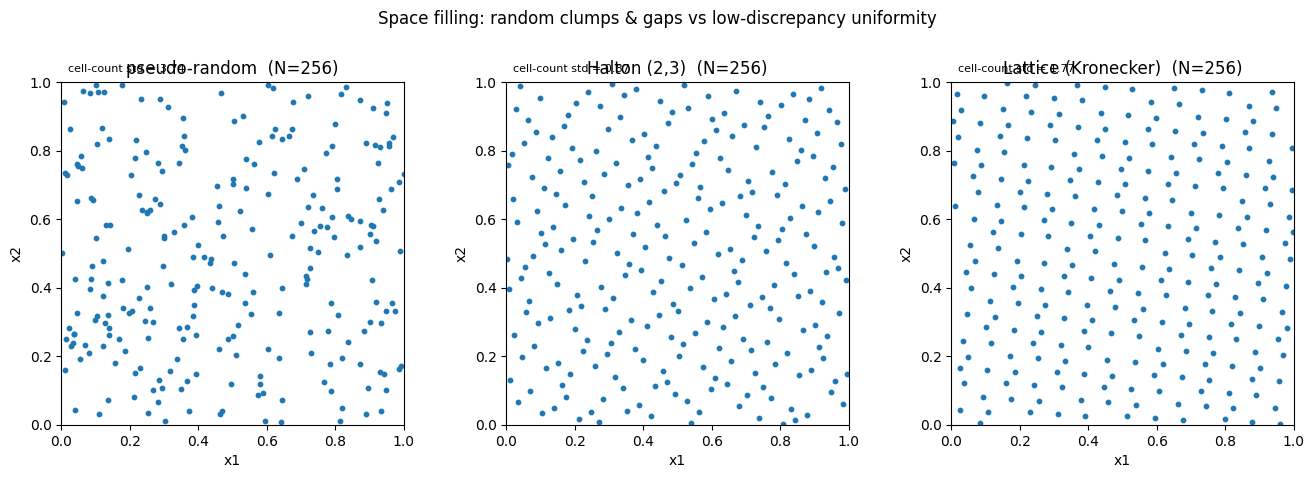

In [2]:
# --- (a) 같은 N에서 점 분포 비교: pseudo-random / Halton / Lattice ---
N = 256
pts = {
    "pseudo-random": rng.random((N, 2)),
    "Halton (2,3)": halton(N, 2),
    "Lattice (Kronecker)": lattice(N, 2),
}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, (name, P) in zip(axes, pts.items()):
    ax.scatter(P[:, 0], P[:, 1], s=10)
    ax.set_title(f"{name}  (N={N})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    H, _, _ = np.histogram2d(P[:, 0], P[:, 1], bins=4, range=[[0, 1], [0, 1]])
    ax.text(0.02, 1.03, f"cell-count std = {H.std():.2f}", fontsize=8)
fig.suptitle("Space filling: random clumps & gaps vs low-discrepancy uniformity", y=1.04)
plt.tight_layout(); plt.show()


In [3]:
# --- (b) 적분 추정: 매끄러운 g(x)=exp(sum x_i), I=(e-1)^d ---
def g_exp(X):
    return np.exp(X.sum(axis=1))
def I_exp(d):
    return (np.e - 1.0) ** d

def estimate(method, d, N):
    if method == "MC":
        X = rng.random((N, d))
    elif method == "Halton":
        X = halton(N, d)
    else:  # Lattice
        X = lattice(N, d)
    return g_exp(X).mean()

Ns = np.unique(np.logspace(2, 4.3, 14).astype(int))
results = {}
for d in [2, 4]:
    It = I_exp(d)
    err = {m: [] for m in ["MC", "Halton", "Lattice"]}
    for N in Ns:
        for m in err:
            if m == "MC":
                e = np.mean([abs(estimate(m, d, int(N)) - It) for _ in range(20)])
            else:
                e = abs(estimate(m, d, int(N)) - It)
            err[m].append(e)
    results[d] = err

df = pd.DataFrame({"N": Ns, **{m: results[2][m] for m in results[2]}})
df


,N,MC,Halton,Lattice
0,100,0.0875651,0.0711938,0.0203481
1,150,0.0599106,0.0495781,0.0272368
2,225,0.0643649,0.0282724,0.0542972
3,339,0.0575835,0.0257563,0.0185298
4,510,0.0509269,0.0120316,0.0028357
5,766,0.0340872,0.0106232,0.00292298
6,1152,0.0266578,0.00679274,0.00395777
7,1731,0.0219201,0.0052698,0.00192598
8,2602,0.0145217,0.00440504,0.00193099
9,3911,0.0216388,0.00221833,0.00223041


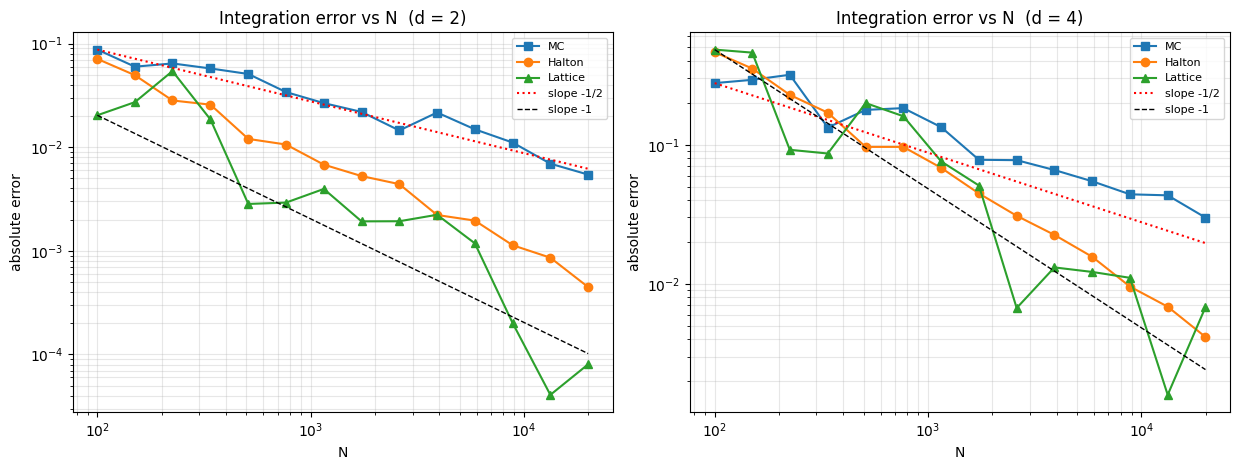

empirical log-log slopes:
  d=2  MC      : -0.497
  d=2  Halton  : -0.911
  d=2  Lattice : -1.167
  d=4  MC      : -0.443
  d=4  Halton  : -0.868
  d=4  Lattice : -0.939


In [4]:
# --- 수렴 그래프: MC(-1/2) vs QMC(~ -1) ---
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, d in zip(axes, [2, 4]):
    err = results[d]
    for m, mk in zip(["MC", "Halton", "Lattice"], ["s-", "o-", "^-"]):
        ax.loglog(Ns, err[m], mk, label=m)
    ax.loglog(Ns, err["MC"][0] * (Ns/Ns[0])**-0.5, "r:", lw=1.5, label="slope -1/2")
    ax.loglog(Ns, err["Lattice"][0] * (Ns/Ns[0])**-1.0, "k--", lw=1, label="slope -1")
    ax.set_title(f"Integration error vs N  (d = {d})")
    ax.set_xlabel("N"); ax.set_ylabel("absolute error")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("empirical log-log slopes:")
for d in [2, 4]:
    for m in ["MC", "Halton", "Lattice"]:
        s = np.polyfit(np.log(Ns), np.log(results[d][m]), 1)[0]
        print(f"  d={d}  {m:8s}: {s:+.3f}")



## 4. 결과 해석

1. **점 분포 (a)**: 유사난수는 군데군데 **뭉치고 빈 구멍**이 생긴다(cell-count std 큼).
   Halton·Lattice 는 4x4 셀에 점이 거의 고르게 떨어져 std 가 작다 -> *낮은 불일치*.
2. **수렴 (b)**: MC 의 경험 기울기는 $\approx-0.5$, Halton/Lattice 는 $d=2$ 에서 $-1$ 에
   가깝다 — 같은 $N$ 에서 QMC 오차가 수십~수백 배 작다.
3. **차원 효과**: $d=4$ 에서는 $(\log N)^d$ 항 때문에 QMC 기울기가 $-1$ 보다 약간 완만하지만
   여전히 MC 의 $-0.5$ 를 크게 앞선다.
4. **Koksma-Hlawka 의 그림**: "골고루 채움(작은 $D_N^*$)" -> "작은 적분오차"가 그대로 보인다.
5. **결정론성의 대가**: QMC 점은 무작위가 아니므로 *표준오차*가 자동으로 안 나온다 —
   신뢰구간을 어떻게 얻을지가 다음 문제의 숙제.

> **결론**: 점을 "무작위"가 아니라 "골고루" 두면, 차수가 $N^{-1/2}\to N^{-1}$ 로 도약한다 —
> 불일치를 줄이는 것이 곧 오차를 줄이는 것이다.

**다음 문제로의 연결**: QMC 의 약점(오차막대 부재, 고차원에서 $(\log N)^d$ 의 부담)을
**랜덤화 QMC(랜덤 시프트)** 로 보완한다 — CE 10.2-3 에서 불편추정량과
경험분산, 그리고 차원이 커질 때 QMC 이득이 어떻게 식는지를 정량화한다.
